# Priorización de clientes para campañas de depósito a plazo
### Data Mining Tools (CC209) · Trabajo Parcial (TP1)

**Universidad Peruana de Ciencias Aplicadas** · Docente: Carlos Fernando Montoya Cubas

**Integrantes:** _(completar con los nombres del grupo)_

Este notebook contiene el primer corte formal del proyecto: definición del problema, documentación del dataset,
calidad de datos, análisis exploratorio guiado por preguntas, preparación reproducible, separación de datos,
baselines, modelos preliminares, evaluación y el plan hacia el Trabajo Final (TF1).

> **Convención de lectura.** En cada análisis se separa **lo que muestran los datos** (hecho verificable en la salida
> de la celda) de **la interpretación del grupo** (hipótesis que todavía no está demostrada).

## 1. Definición del problema

| Elemento | Descripción |
|---|---|
| **Contexto** | Un banco portugués realizó campañas de *telemarketing* (2008–2010) para ofrecer depósitos a plazo. Cada llamada tiene un costo operativo (tiempo del agente) y un costo reputacional (insistir a clientes no interesados). |
| **Necesidad** | Con recursos limitados de llamadas, el banco necesita decidir **a quién llamar primero**. Llamar a todos es caro y solo ~11 % de los contactos termina en suscripción. |
| **Unidad de análisis** | Un contacto de campaña: un cliente contactado en una campaña, con sus datos personales, historial de contacto y contexto macroeconómico del momento. |
| **Pregunta principal** | *Antes de realizar la llamada*, ¿qué probabilidad tiene un cliente de suscribir un depósito a plazo, y permite esa probabilidad ordenar a los clientes de modo que se capten más suscriptores con menos llamadas? |
| **Tipo de problema** | Clasificación binaria supervisada con clases desbalanceadas, usada como **ranking** (priorización). |
| **Utilidad esperada** | Una lista priorizada de clientes para cada campaña, que concentre a los suscriptores probables en el primer tramo de llamadas. |

**Criterios de utilidad (definidos antes de modelar):**
1. La **PR-AUC** del modelo debe superar claramente a la prevalencia (≈ 0.113, que es lo que obtiene un modelo trivial) y a una regla simple de negocio.
2. Llamando solo al **20 % de clientes con mayor score**, se debe captar al menos el **40 % de los suscriptores** (el doble de lo que se obtendría llamando al azar).
3. El modelo solo puede usar información **disponible antes de la llamada** (sin data leakage).

## 2. Dataset y procedencia

| Aspecto | Detalle |
|---|---|
| **Nombre** | Bank Marketing — archivo `bank-additional-full.csv` |
| **Fuente** | UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/222/bank+marketing |
| **Autores / cita** | Moro, S., Cortez, P. y Rita, P. (2014). *A Data-Driven Approach to Predict the Success of Bank Telemarketing.* Decision Support Systems, 62, 22–31. |
| **Licencia** | Creative Commons Attribution 4.0 (CC BY 4.0): permite uso académico citando la fuente. |
| **Observaciones / variables** | 41 188 filas × 21 columnas (20 predictores + objetivo `y`). |
| **Período** | Mayo 2008 – noviembre 2010. Los registros están **ordenados por fecha**, pero no existe una columna de año (solo `month` y `day_of_week`). |
| **Variable objetivo** | `y`: ¿el cliente suscribió un depósito a plazo? (`yes` / `no`). |

**¿Por qué es adecuado para el problema?** Contiene variables del cliente, del contacto, del historial de campañas y
del contexto económico; mezcla variables numéricas y categóricas; presenta problemas de calidad reales (categorías
`unknown`, valores centinela, duplicados, reglas lógicas inconsistentes), desbalance de clases y un caso documentado de
data leakage (`duration`). Es rico para EDA, preparación, modelamiento y evaluación, y su tamaño permite iterar rápido.

**Limitaciones conocidas:** un solo banco y un solo país; período de crisis financiera (2008–2010) con cambios de
contexto fuertes; sin identificador de cliente (un mismo cliente puede aparecer varias veces); sin información de
costos ni del monto depositado; versión pública con algunos atributos anonimizados o agregados por los autores.

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  ConfusionMatrixDisplay, PrecisionRecallDisplay, average_precision_score, confusion_matrix,
  f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Rutas: el CSV debe estar en la misma carpeta que el notebook
RAW_PATH = Path('bank-additional-full.csv')
REPORTS_DIR = Path('reports')
FIGURES_DIR = REPORTS_DIR / 'figures'
MODELS_DIR = Path('models')

RANDOM_STATE = 42
TARGET = 'y'
LEAKAGE_COLS = ['duration']  # solo se conoce después de la llamada

MACRO_NUM = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
# 'contacto_reciente' se crea en el pipeline a partir de pdays (sección 7)
NUM_FEATURES = ['age', 'campaign', 'previous', 'contacto_reciente'] + MACRO_NUM
CAT_FEATURES = [
  'job', 'marital', 'education', 'default', 'housing', 'loan',
  'contact', 'month', 'day_of_week', 'poutcome',
]

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', 30)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
COLOR_NO, COLOR_YES = '#9AA5B1', '#C2410C'
RESULTS = {}


def save(fig, name):
  fig.savefig(FIGURES_DIR / f'{name}.png', dpi=150, bbox_inches='tight')


In [2]:
def load_raw(path=RAW_PATH):
  """Lee el CSV original de UCI (separado por ';')."""
  return pd.read_csv(path, sep=';')


raw = load_raw()
print('Archivo:', RAW_PATH.name)
print('Dimensiones:', raw.shape)
raw.head()


Archivo: bank-additional-full.csv
Dimensiones: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

### Diccionario de variables

| Grupo | Variable | Tipo | Descripción |
|---|---|---|---|
| Cliente | `age` | numérica | Edad |
| Cliente | `job` | categórica | Ocupación (12 categorías, incluye `unknown`) |
| Cliente | `marital` | categórica | Estado civil |
| Cliente | `education` | categórica | Nivel educativo |
| Cliente | `default` | categórica | ¿Tiene crédito en mora? |
| Cliente | `housing` | categórica | ¿Tiene préstamo hipotecario? |
| Cliente | `loan` | categórica | ¿Tiene préstamo personal? |
| Contacto | `contact` | categórica | Canal: `cellular` o `telephone` |
| Contacto | `month`, `day_of_week` | categóricas | Mes y día de la semana del último contacto |
| Contacto | `duration` | numérica | Duración de la última llamada en segundos. **⚠ Leakage: solo se conoce después de llamar** |
| Campaña | `campaign` | numérica | Número de contactos en esta campaña (incluye el actual) |
| Campaña | `pdays` | numérica | Días desde el último contacto de una campaña previa (`999` = sin contacto previo) |
| Campaña | `previous` | numérica | Número de contactos antes de esta campaña |
| Campaña | `poutcome` | categórica | Resultado de la campaña anterior: `success`, `failure`, `nonexistent` |
| Macro | `emp.var.rate` | numérica | Tasa de variación del empleo (trimestral) |
| Macro | `cons.price.idx` | numérica | Índice de precios al consumidor (mensual) |
| Macro | `cons.conf.idx` | numérica | Índice de confianza del consumidor (mensual) |
| Macro | `euribor3m` | numérica | Tasa Euríbor a 3 meses (diaria) |
| Macro | `nr.employed` | numérica | Número de empleados (trimestral) |
| Objetivo | `y` | binaria | ¿Suscribió el depósito a plazo? |

## 3. Calidad de datos

Se revisan valores faltantes, duplicados, tipos, categorías inconsistentes, outliers, reglas lógicas de negocio y
riesgo de leakage. Cada hallazgo termina en una **decisión justificada**.

In [4]:
# 3.1 Valores faltantes explícitos y codificados como 'unknown'
na = raw.isna().sum().sum()
print('Valores NaN explícitos en todo el dataset:', na)

cat_cols = [c for c in raw.columns if c not in raw.select_dtypes('number').columns]
target_bin = (raw[TARGET] == 'yes').astype(int)
rows = []
for c in cat_cols:
  mask = raw[c] == 'unknown'
  if mask.any():
    rows.append({
      'variable': c,
      'n_unknown': int(mask.sum()),
      'pct_unknown': round(100 * mask.mean(), 2),
      'tasa_si_unknown': round(target_bin[mask].mean(), 3),
      'tasa_si_resto': round(target_bin[~mask].mean(), 3),
    })
unknown_df = pd.DataFrame(rows).sort_values('pct_unknown', ascending=False)
unknown_df

Valores NaN explícitos en todo el dataset: 0


,variable,n_unknown,pct_unknown,tasa_si_unknown,tasa_si_resto
3,default,8597,20.87,0.052,0.129
2,education,1731,4.20,0.145,0.111
4,housing,990,2.40,0.108,0.113
5,loan,990,2.40,0.108,0.113
0,job,330,0.80,0.112,0.113
1,marital,80,0.19,0.150,0.113


**Lo que muestran los datos.** No hay `NaN` explícitos, pero seis variables categóricas usan `unknown` como valor
faltante. El caso más fuerte es `default`, con ~21 % de `unknown`. Su tasa de suscripción (≈ 5 %) es **menos de la
mitad** que la del resto (≈ 13 %).

**Interpretación.** La falta de información no es aleatoria: probablemente refleja clientes de los que el banco sabe
menos o que no quisieron declarar su situación crediticia. Imputar con la moda (`no`) borraría esa señal.

**Decisión.** Conservar `unknown` como **categoría propia** en todas las variables. No se eliminan filas: se
perderían ~26 % de los registros y el sesgo sería sistemático.

In [5]:
# 3.2 Duplicados
dup_full = raw.duplicated().sum()
dup_sin_duration = raw.drop(columns=['duration']).duplicated().sum()
print(f'Duplicados exactos (todas las columnas): {dup_full}')
print(f'Duplicados si se ignora duration:        {dup_sin_duration}')

Duplicados exactos (todas las columnas): 12
Duplicados si se ignora duration:        1784


**Lo que muestran los datos.** Hay 12 filas idénticas en todas las columnas. Si se ignora `duration`, el número de
coincidencias sube a ~1 784.

**Interpretación.** Que dos llamadas coincidan además en su duración exacta en segundos es muy improbable, por lo que
las 12 filas se tratan como **registros repetidos por error de carga**. Las ~1 784 coincidencias sin `duration` sí
pueden ser clientes distintos con el mismo perfil y el mismo contexto (las variables macro solo tienen unas pocas
decenas de valores), así que no se eliminan.

**Decisión.** Eliminar únicamente los 12 duplicados exactos (0.03 % de los datos). **Incertidumbre:** sin un ID de
cliente no podemos confirmar si un mismo cliente aparece en varias campañas; esto puede hacer que el split aleatorio
sea ligeramente optimista.

In [6]:
# 3.3 Tipos de datos y categorías (revisión de consistencia)
for c in cat_cols:
  vals = raw[c].value_counts()
  print(f'{c:12s} ({len(vals):2d} categorías):', vals.tail(3).to_dict())

job          (12 categorías): {'unemployed': 1014, 'student': 875, 'unknown': 330}
marital      ( 4 categorías): {'single': 11568, 'divorced': 4612, 'unknown': 80}
education    ( 8 categorías): {'basic.6y': 2292, 'unknown': 1731, 'illiterate': 18}
default      ( 3 categorías): {'no': 32588, 'unknown': 8597, 'yes': 3}
housing      ( 3 categorías): {'yes': 21576, 'no': 18622, 'unknown': 990}
loan         ( 3 categorías): {'no': 33950, 'yes': 6248, 'unknown': 990}
contact      ( 2 categorías): {'cellular': 26144, 'telephone': 15044}
month        (10 categorías): {'sep': 570, 'mar': 546, 'dec': 182}
day_of_week  ( 5 categorías): {'wed': 8134, 'tue': 8090, 'fri': 7827}
poutcome     ( 3 categorías): {'nonexistent': 35563, 'failure': 4252, 'success': 1373}
y            ( 2 categorías): {'no': 36548, 'yes': 4640}


**Lo que muestran los datos.** Las categorías están escritas de forma consistente (sin variantes de mayúsculas ni
espacios). Aparecen categorías muy raras: `default = yes` (3 filas) y `education = illiterate` (18 filas). `month`
solo tiene 10 meses: no hay contactos en enero ni febrero.

**Decisión.** No se fusionan categorías manualmente. El `OneHotEncoder` agrupa automáticamente las categorías con menos
de 10 casos **en train** (`min_frequency=10`) y usa `handle_unknown='ignore'` para no fallar ante categorías nuevas en
producción. Los tipos de datos son correctos: las numéricas son `int`/`float` y las categóricas son texto.

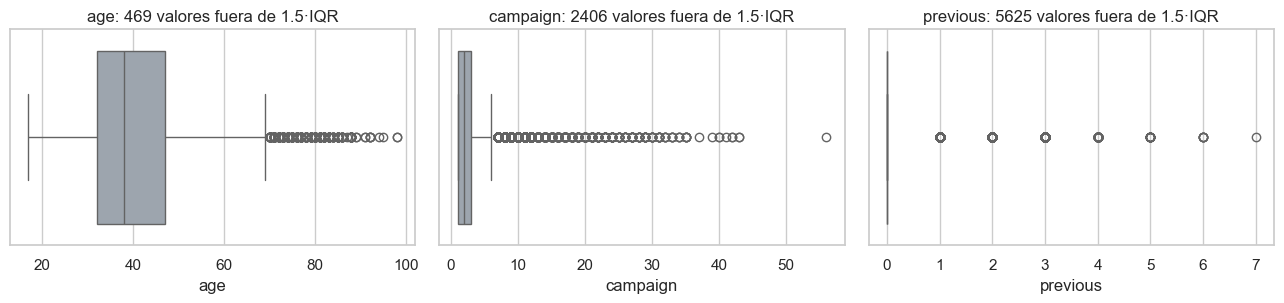

Percentiles de campaign: {0.5: 2.0, 0.9: 5.0, 0.95: 7.0, 0.99: 14.0}
Clientes con más de 70 años: 422 | tasa de suscripción: 0.479


In [7]:
# 3.4 Outliers en variables numéricas de cliente y campaña
num_check = ['age', 'campaign', 'previous']
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, c in zip(axes, num_check):
  sns.boxplot(x=raw[c], ax=ax, color=COLOR_NO)
  q1, q3 = raw[c].quantile([0.25, 0.75])
  n_out = ((raw[c] < q1 - 1.5 * (q3 - q1)) | (raw[c] > q3 + 1.5 * (q3 - q1))).sum()
  ax.set_title(f'{c}: {n_out} valores fuera de 1.5·IQR')
plt.tight_layout()
save(fig, 'outliers')
plt.show()

print('Percentiles de campaign:', raw['campaign'].quantile([0.5, 0.9, 0.95, 0.99]).to_dict())
print('Clientes con más de 70 años:', (raw['age'] > 70).sum(),
      '| tasa de suscripción:', round(target_bin[raw['age'] > 70].mean(), 3))

**Lo que muestran los datos.** `age` tiene valores altos (hasta 98) y `campaign` tiene una cola larga (mediana 2, p99 =
14, máximo 56). `previous` está concentrada en 0, así que la regla IQR marca como outlier a todo cliente con
contacto previo.

**Interpretación.** Ninguno de estos valores es imposible. Los clientes mayores de 70 años son reales y, además, muy
informativos (≈ 48 % de suscripción), por lo que eliminarlos destruiría señal. La regla IQR no es apropiada para
variables de conteo con muchos ceros.

**Decisión.** No se eliminan filas. Solo se **recorta `campaign` en su percentil 99**, calculado **únicamente con
train** dentro del pipeline (`QuantileClipper`). Así se evita que unos pocos clientes muy insistidos dominen el escalado
de la regresión logística. Los modelos de árboles no se ven afectados por esta decisión.

In [8]:
# 3.5 Reglas lógicas: coherencia entre pdays, previous y poutcome
print(pd.crosstab(raw['pdays'] == 999, raw['previous'] == 0,
                  rownames=['pdays == 999'], colnames=['previous == 0']))
print()
print(pd.crosstab(raw['poutcome'], raw['pdays'] == 999, colnames=['pdays == 999']))

previous == 0  False  True 
pdays == 999               
False           1515      0
True            4110  35563

pdays == 999  False  True 
poutcome                  
failure         142   4110
nonexistent       0  35563
success        1373      0


**Lo que muestran los datos.** La regla esperada es que `pdays = 999` (sin contacto previo) implique `previous = 0`.
Sin embargo, **4 110 filas** tienen `pdays = 999` y `previous > 0`, y todas tienen `poutcome = failure`. En cambio,
`poutcome = nonexistent` coincide exactamente con `previous = 0`.

**Interpretación.** `pdays` parece no estar registrado para parte de los clientes con contacto previo. Además, `999` no
es una distancia real en días: si se usara como número, la regresión logística lo trataría como "999 días después".

**Decisión.** Reemplazar `pdays` por un indicador binario `contacto_reciente = (pdays != 999)` y confiar en `previous`
y `poutcome` para el historial, ya que son consistentes entre sí. Esta transformación es una regla fija, sin
parámetros aprendidos, y se implementa en el pipeline (`ContactHistoryFeatures`).

ROC-AUC usando solo duration: 0.818
Llamadas con duration = 0: 4 -> y: {'no': 4}


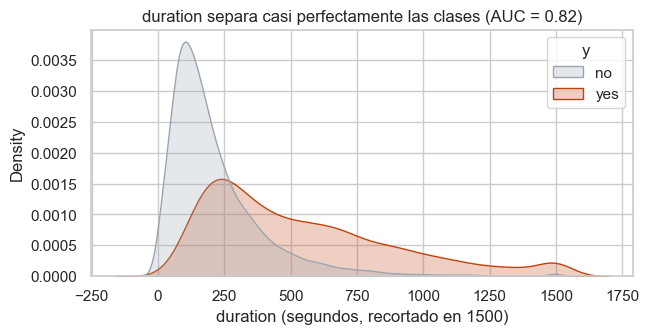

In [9]:
# 3.6 Data leakage: poder predictivo de duration por sí sola
auc_duration = roc_auc_score(target_bin, raw['duration'])
print(f'ROC-AUC usando solo duration: {auc_duration:.3f}')
print('Llamadas con duration = 0:', (raw['duration'] == 0).sum(),
      '-> y:', raw.loc[raw['duration'] == 0, TARGET].value_counts().to_dict())

fig, ax = plt.subplots(figsize=(7, 3.2))
sns.kdeplot(data=raw.assign(dur=raw['duration'].clip(upper=1500)), x='dur', hue=TARGET,
            common_norm=False, fill=True, palette={'no': COLOR_NO, 'yes': COLOR_YES}, ax=ax)
ax.set_xlabel('duration (segundos, recortado en 1500)')
ax.set_title(f'duration separa casi perfectamente las clases (AUC = {auc_duration:.2f})')
save(fig, 'leakage_duration')
plt.show()
RESULTS['auc_duration'] = round(float(auc_duration), 3)

**Lo que muestran los datos.** Por sí sola, `duration` alcanza un ROC-AUC de ≈ 0.82, y todas las llamadas con duración 0
terminan en `no`.

**Interpretación.** `duration` es consecuencia del resultado, no una causa observable de antemano. Una llamada larga
ocurre *porque* el cliente está interesado, y la duración solo se conoce cuando la llamada ya terminó. La propia
documentación de UCI recomienda excluirla en modelos predictivos realistas.

**Decisión.** **Eliminar `duration`** antes de cualquier modelamiento. Incluirla daría métricas infladas e inútiles para
el objetivo, que es decidir a quién llamar *antes* de llamar.

In [10]:
def basic_clean(raw):
  """Elimina duplicados exactos y la variable con leakage; codifica y como 0/1.

  Son reglas fijas fila a fila (no usan estadísticos del conjunto). Los duplicados se eliminan antes de
  quitar duration, para que solo cuenten las filas idénticas en todas las columnas. Se conserva el
  orden original (cronológico) de los registros.
  """
  df = raw.drop_duplicates().drop(columns=LEAKAGE_COLS).reset_index(drop=True)
  df[TARGET] = (df[TARGET] == 'yes').astype(int)
  return df


def split_xy(df):
  return df.drop(columns=[TARGET]), df[TARGET]


df = basic_clean(raw)
print('Dimensiones después de la limpieza:', df.shape)
print('Tasa de suscripción:', round(df[TARGET].mean(), 4))


Dimensiones después de la limpieza: (41176, 20)
Tasa de suscripción: 0.1127


## 4. Análisis exploratorio guiado por preguntas

El EDA se organiza en seis preguntas que condicionan decisiones posteriores de preparación, modelamiento o evaluación.

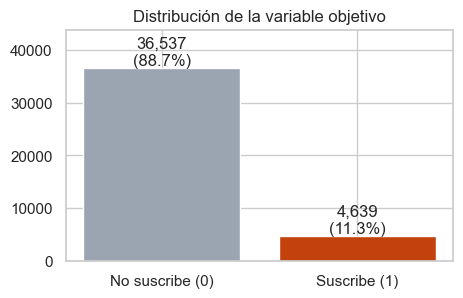

In [11]:
# P1. ¿Qué tan desbalanceada está la variable objetivo?
counts = df[TARGET].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['No suscribe (0)', 'Suscribe (1)'], counts.values, color=[COLOR_NO, COLOR_YES])
for i, v in enumerate(counts.values):
  ax.text(i, v, f'{v:,}\n({v / counts.sum():.1%})', ha='center', va='bottom')
ax.set_ylim(0, counts.max() * 1.2)
ax.set_title('Distribución de la variable objetivo')
save(fig, 'eda_target')
plt.show()
RESULTS['n_filas'] = int(len(df))
RESULTS['prevalencia'] = round(float(df[TARGET].mean()), 4)

**P1. ¿Qué tan desbalanceada está la variable objetivo?**

**Lo que muestran los datos.** Solo ≈ 11.3 % de los contactos termina en suscripción (≈ 4 640 de ≈ 41 180).

**Implicaciones.**
- La **accuracy no sirve**: un modelo que siempre dice "no" obtiene ≈ 88.7 %.
- La métrica principal será la **PR-AUC (average precision)**, que se centra en la clase positiva y cuyo valor de
  referencia por azar es la prevalencia (0.113). Además se reportan ROC-AUC, precisión/recall/F1 en un umbral elegido
  en validación y el **% de suscriptores captados en el top 20 %**, que traduce el resultado al problema de negocio.
- El split debe ser **estratificado**, y en la regresión logística y el random forest se usa `class_weight` para que
  la clase minoritaria tenga peso en el entrenamiento.

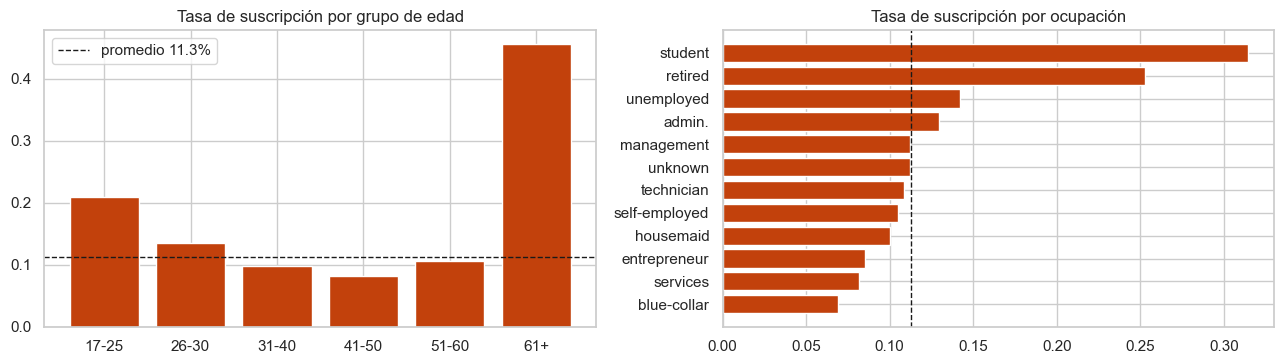

age,17-25,26-30,31-40,41-50,51-60,61+
mean,0.21,0.136,0.097,0.082,0.107,0.455
size,1665.00,5716.000,16380.000,10237.000,6269.000,909.000


In [12]:
# P2. ¿El perfil del cliente (edad, ocupación) se asocia con la suscripción?
base_rate = df[TARGET].mean()
age_bins = pd.cut(df['age'], [16, 25, 30, 40, 50, 60, 100],
                  labels=['17-25', '26-30', '31-40', '41-50', '51-60', '61+'])
by_age = df.groupby(age_bins, observed=True)[TARGET].agg(['mean', 'size'])
by_job = df.groupby('job')[TARGET].agg(['mean', 'size']).sort_values('mean')

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].bar(by_age.index.astype(str), by_age['mean'], color=COLOR_YES)
axes[1].barh(by_job.index, by_job['mean'], color=COLOR_YES)
axes[0].axhline(base_rate, ls='--', c='k', lw=1, label=f'promedio {base_rate:.1%}')
axes[1].axvline(base_rate, ls='--', c='k', lw=1)
axes[0].set_title('Tasa de suscripción por grupo de edad'); axes[0].legend()
axes[1].set_title('Tasa de suscripción por ocupación')
plt.tight_layout()
save(fig, 'eda_perfil')
plt.show()
by_age.round(3).T

**P2. ¿El perfil del cliente se asocia con la suscripción?**

**Lo que muestran los datos.** La relación con la edad tiene forma de **U**: los jóvenes de 17 a 25 años (≈ 21 %) y
sobre todo los mayores de 60 (≈ 46 %) suscriben mucho más que el grupo de 31 a 50 años (≈ 8–10 %). Por ocupación,
`student` (≈ 31 %) y `retired` (≈ 25 %) duplican o triplican el promedio, mientras que `blue-collar` (≈ 7 %) queda
por debajo.

**Interpretación (hipótesis).** Estudiantes y jubilados podrían tener más disponibilidad para atender llamadas y una
mayor preferencia por productos de ahorro de bajo riesgo. Edad y ocupación están relacionadas entre sí (los
`retired` son mayores), así que no son efectos independientes.

**Implicación.** La relación no lineal con la edad favorece a los modelos de árboles. Para la regresión logística sería
útil discretizar la edad o agregar términos no lineales (pendiente para el TF1).

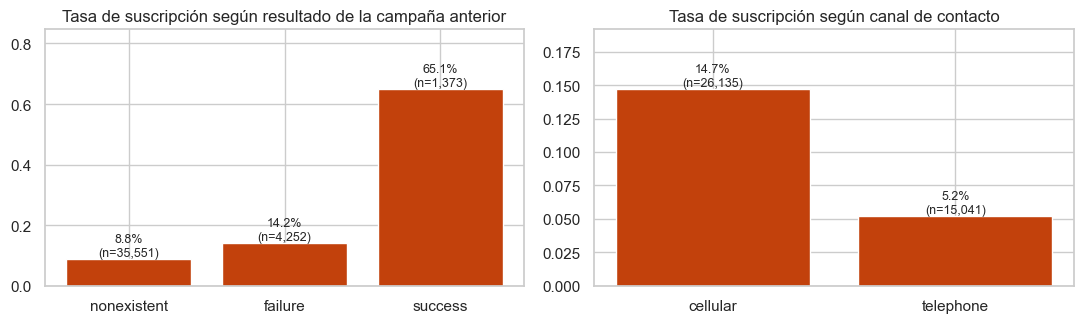

In [13]:
# P3. ¿El historial de contacto previo anticipa la respuesta?
by_pout = df.groupby('poutcome')[TARGET].agg(['mean', 'size']).sort_values('mean')
by_contact = df.groupby('contact')[TARGET].agg(['mean', 'size'])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(by_pout.index, by_pout['mean'], color=COLOR_YES)
axes[0].set_title('Tasa de suscripción según resultado de la campaña anterior')
axes[1].bar(by_contact.index, by_contact['mean'], color=COLOR_YES)
axes[1].set_title('Tasa de suscripción según canal de contacto')
for ax, tab in zip(axes, [by_pout, by_contact]):
  for i, (m, n) in enumerate(zip(tab['mean'], tab['size'])):
    ax.text(i, m, f'{m:.1%}\n(n={n:,})', ha='center', va='bottom', fontsize=9)
  ax.set_ylim(0, tab['mean'].max() * 1.3)
plt.tight_layout()
save(fig, 'eda_historial')
plt.show()
RESULTS['tasa_poutcome'] = by_pout['mean'].round(3).to_dict()

**P3. ¿El historial de contacto anticipa la respuesta?**

**Lo que muestran los datos.** Los clientes que suscribieron en la campaña anterior (`poutcome = success`) vuelven a
suscribir en ≈ 65 % de los casos, frente a ≈ 9 % de quienes nunca fueron contactados. Además, contactar por celular
(≈ 15 %) rinde casi tres veces más que por teléfono fijo (≈ 5 %).

**Interpretación (hipótesis).** El éxito previo refleja afinidad con el producto y confianza en el banco. La diferencia
por canal podría deberse al perfil de quienes usan fijo o a la época (el canal fijo predomina en los primeros meses),
así que **no es necesariamente un efecto causal del canal**.

**Implicación.** `poutcome = success` es tan fuerte que sirve como **baseline de negocio**: "llamar solo a quienes
suscribieron antes". Pero cubre a pocos clientes (≈ 3 %), por lo que el modelo debe aportar en el resto de la base.

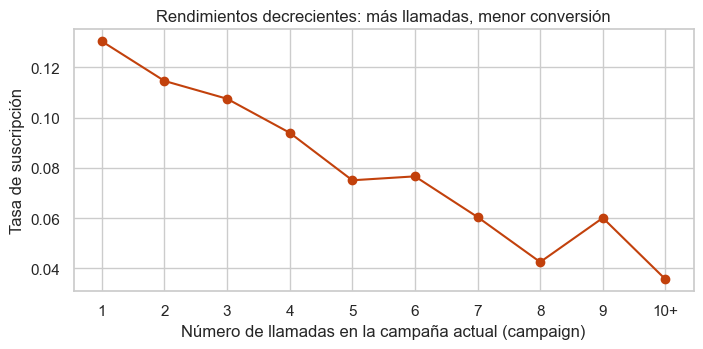

campaign,1,2,3,4,5,6,7,8,9,10
mean,0.13,0.115,0.107,0.094,0.075,0.077,0.06,0.042,0.06,0.036
size,17634.00,10568.000,5340.000,2650.000,1599.000,979.000,629.00,400.000,283.00,1094.000


In [14]:
# P4. ¿Insistir con más llamadas en la misma campaña aumenta la conversión?
calls = df['campaign'].clip(upper=10)
by_calls = df.groupby(calls)[TARGET].agg(['mean', 'size'])

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(by_calls.index, by_calls['mean'], marker='o', color=COLOR_YES)
ax.set_xticks(range(1, 11), [str(i) for i in range(1, 10)] + ['10+'])
ax.set_xlabel('Número de llamadas en la campaña actual (campaign)')
ax.set_ylabel('Tasa de suscripción')
ax.set_title('Rendimientos decrecientes: más llamadas, menor conversión')
save(fig, 'eda_campaign')
plt.show()
RESULTS['tasa_por_llamadas'] = {int(k): round(float(v), 3) for k, v in by_calls['mean'].items()}
by_calls.round(3).T

**P4. ¿Insistir con más llamadas aumenta la conversión?**

**Lo que muestran los datos.** La tasa de suscripción cae de forma casi monótona: ≈ 13 % en la primera llamada, ≈ 7–8 %
entre la quinta y la sexta, y ≈ 4–6 % a partir de la octava.

**Interpretación.** Hay rendimientos decrecientes: insistir no convierte, y probablemente desgasta la relación con el
cliente. **Precaución:** `campaign` se mide en el último contacto, así que quien suscribe en la primera llamada ya no
recibe más; parte de esta caída es mecánica.

**Implicación.** `campaign` tiene una cola larga que justifica el recorte en p99. Para el TF1 queda pendiente analizar si
`campaign` es realmente conocida en el momento de decidir la llamada; si se usa para decidir el **primer** contacto, su
valor sería 1 para todos.

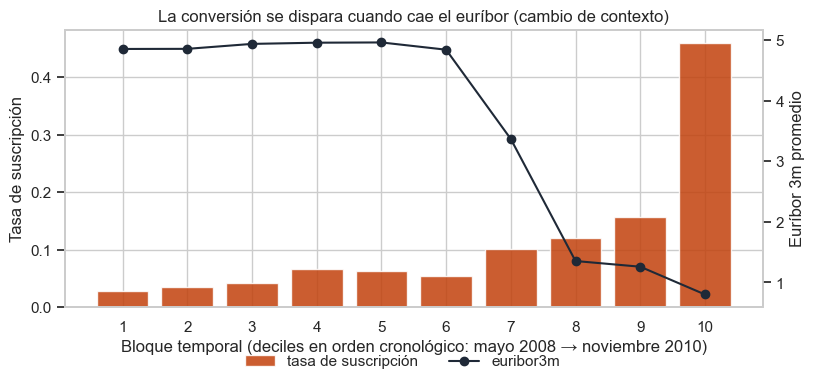

,tasa,euribor,mes_inicio,mes_fin
bloque_temporal,,,,
1,0.028,4.857,may,may
2,0.035,4.859,may,jun
3,0.042,4.941,jun,jul
4,0.066,4.961,jul,jul
5,0.062,4.965,jul,aug
6,0.055,4.845,aug,nov
7,0.102,3.370,nov,apr
8,0.120,1.354,apr,may
9,0.157,1.260,may,jul


In [15]:
# P5. ¿Cambia la tasa de suscripción en el tiempo? (los registros están ordenados por fecha)
block = pd.Series(np.arange(len(df)) * 10 // len(df) + 1, name='bloque_temporal')
by_block = df.groupby(block).agg(tasa=(TARGET, 'mean'), euribor=('euribor3m', 'mean'),
                                 mes_inicio=('month', 'first'), mes_fin=('month', 'last'))

fig, ax1 = plt.subplots(figsize=(9, 3.6))
ax1.bar(by_block.index, by_block['tasa'], color=COLOR_YES, alpha=0.85, label='tasa de suscripción')
ax1.set_xlabel('Bloque temporal (deciles en orden cronológico: mayo 2008 → noviembre 2010)')
ax1.set_ylabel('Tasa de suscripción')
ax2 = ax1.twinx()
ax2.plot(by_block.index, by_block['euribor'], color='#1F2937', marker='o', label='euribor3m')
ax2.set_ylabel('Euríbor 3m promedio'); ax2.grid(False)
ax1.set_xticks(range(1, 11))
ax1.set_title('La conversión se dispara cuando cae el euríbor (cambio de contexto)')
fig.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.1), frameon=False)
save(fig, 'eda_temporal')
plt.show()
RESULTS['tasa_por_bloque'] = by_block['tasa'].round(3).tolist()
RESULTS['euribor_por_bloque'] = by_block['euribor'].round(2).tolist()
by_block.round(3)

**P5. ¿Cambia la tasa de suscripción en el tiempo?**

**Lo que muestran los datos.** Dividiendo los registros en 10 bloques cronológicos, la tasa sube de ≈ 3 % en el primer
bloque a ≈ 46 % en el último. Al mismo tiempo, el euríbor a 3 meses cae de ≈ 4.9 % a menos de 1 %. Los meses con
pocas llamadas (`mar`, `sep`, `oct`, `dec`) tienen tasas de 44–51 %, mientras que `may`, el mes con más llamadas
(≈ 33 % de los registros), queda en ≈ 6 %.

**Interpretación (hipótesis).** Se observan dos fenómenos mezclados:
1. **Cambio de contexto económico:** durante la crisis y con tasas bajas, el depósito a plazo garantizado pudo volverse
   más atractivo.
2. **Cambio de estrategia de la campaña:** en los últimos períodos se hicieron menos llamadas, posiblemente más
   selectivas.

Con estos datos **no podemos separar ambos efectos**.

**Implicación (crítica para el proyecto).** Las variables macro y `month` funcionan casi como un **reloj**: indican en
qué período ocurrió el contacto. Un split aleatorio mezcla todos los períodos en train y test, y puede sobreestimar el
desempeño en una campaña futura. Esto se evalúa explícitamente en la sección 10.

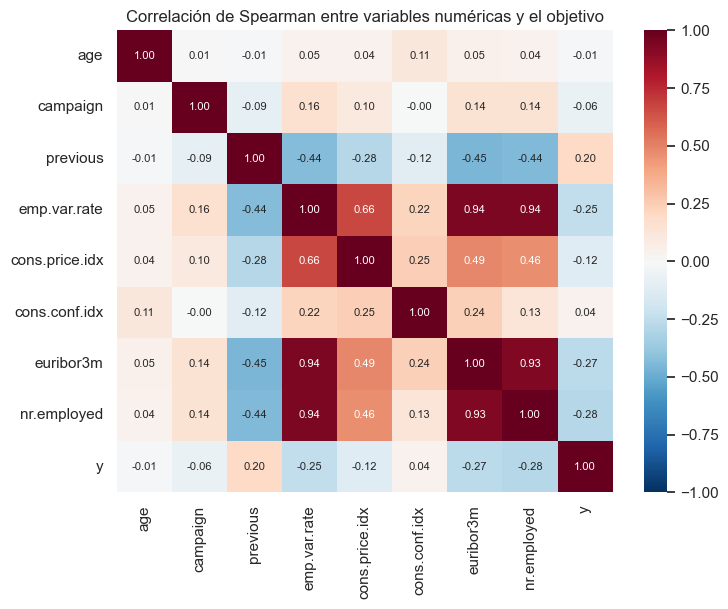

In [16]:
# P6. ¿Qué relación hay entre las variables numéricas? (multicolinealidad)
num_cols = ['age', 'campaign', 'previous'] + MACRO_NUM
corr = df[num_cols + [TARGET]].corr(method='spearman')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlación de Spearman entre variables numéricas y el objetivo')
save(fig, 'eda_correlacion')
plt.show()

**P6. ¿Qué relación hay entre las variables numéricas?**

**Lo que muestran los datos.** Las variables macro están fuertemente correlacionadas entre sí: `euribor3m`,
`emp.var.rate` y `nr.employed` tienen |ρ| > 0.9. Además, son las numéricas más asociadas con el objetivo (correlación
negativa). `age` casi no correlaciona linealmente con `y`, lo cual es coherente con la forma de U de P2.

**Implicación.** La multicolinealidad no afecta la capacidad predictiva, pero vuelve **inestables e ininterpretables**
los coeficientes individuales de la regresión logística, que ya usa regularización L2 por defecto. Para el TF1 se
plantea resumir el bloque macro con **PCA**, justificado por esta redundancia.

## 5. Resumen de decisiones de preparación

| Problema detectado | Evidencia | Decisión | Dónde se aplica | ¿Aprende de los datos? |
|---|---|---|---|---|
| Leakage en `duration` | AUC ≈ 0.82 por sí sola; solo existe tras la llamada | Eliminar la variable | `basic_clean` (antes del split) | No |
| 12 duplicados exactos | Coinciden incluso en duración al segundo | Eliminar | `basic_clean` (antes del split) | No |
| `unknown` en 6 categóricas | Tasa de `y` distinta (p. ej. `default`) | Mantener como categoría | `OneHotEncoder` | Sí → solo con train |
| `pdays = 999` como centinela e inconsistente con `previous` | 4 110 filas contradictorias | Indicador `contacto_reciente`; descartar `pdays` | `ContactHistoryFeatures` | No |
| Cola larga en `campaign` | p99 = 14, máximo = 56 | Recorte en p99 | `QuantileClipper` | Sí → solo con train |
| Escalas distintas | Edad frente a índices macro | `StandardScaler` | `ColumnTransformer` | Sí → solo con train |
| Categorías raras | `default = yes`: 3 filas | Agrupar si n < 10 e ignorar categorías nuevas | `OneHotEncoder` | Sí → solo con train |
| Desbalance (11 %) | P1 | Split estratificado, `class_weight`, PR-AUC | Split y modelos | — |

Las dos operaciones previas al split (eliminar `duration` y los duplicados exactos) son **reglas fijas fila a fila**:
no usan estadísticos del conjunto, por lo que no filtran información de test hacia train.

## 6. Separación de los datos

**Estrategia principal:** hold-out **estratificado 70 / 15 / 15** (train / validation / test) con semilla fija (42).

- **Train (70 %)**: ajuste de todas las transformaciones y de los modelos, y validación cruzada de 5 folds para medir
  estabilidad.
- **Validation (15 %)**: comparación de modelos y elección del umbral de decisión.
- **Test (15 %)**: se usa **una sola vez** al final, para el modelo elegido y los baselines.

**¿Por qué estratificado?** Con 11 % de positivos, la estratificación garantiza la misma prevalencia en las tres
particiones. Unos 6 200 registros por partición dan estimaciones estables, con ~700 positivos en cada una.

**Alternativa considerada: split temporal.** Es más realista para predecir campañas futuras, pero la prevalencia
cambia drásticamente en el tiempo (P5). Por eso se usa como **prueba de estrés** en la sección 10, no como criterio
de selección en este corte. Ver la discusión en limitaciones.

In [17]:
X, y = split_xy(df)
X_train, X_tmp, y_train, y_tmp = train_test_split(
  X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
  X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_STATE
)
split_summary = pd.DataFrame({
  'filas': [len(X_train), len(X_val), len(X_test)],
  'proporcion': [len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)],
  'tasa_suscripcion': [y_train.mean(), y_val.mean(), y_test.mean()],
}, index=['train', 'validation', 'test']).round(3)
split_summary

,filas,proporcion,tasa_suscripcion
train,28823,0.70,0.113
validation,6176,0.15,0.113
test,6177,0.15,0.113


Las tres particiones tienen la misma tasa de suscripción (≈ 0.113), lo que confirma la estratificación.

**Medidas contra data leakage:**
1. `duration` eliminada (leakage de información futura).
2. Todas las transformaciones que aprenden parámetros (escalado, one-hot, percentil de recorte) están **dentro del
   `Pipeline`**, por lo que se ajustan solo con los datos de entrenamiento de cada fit, incluidos cada fold de la
   validación cruzada.
3. El umbral de decisión se elige en **validation**, nunca en test.
4. Test no se usa para ninguna decisión hasta la evaluación final.

## 7. Flujo reproducible de preprocesamiento

El flujo completo se define una sola vez en la celda siguiente y se reutiliza en todos los experimentos del notebook
y en el artefacto de inferencia (sección 13):

```
datos crudos ─► ContactHistoryFeatures ─► QuantileClipper(campaign, p99) ─► ColumnTransformer ─► modelo
                (pdays → contacto_reciente)   (umbral aprendido en train)   ├─ numéricas → StandardScaler
                                                                            └─ categóricas → OneHotEncoder
```

In [18]:
class ContactHistoryFeatures(BaseEstimator, TransformerMixin):
  """Reemplaza el centinela pdays = 999 por el indicador binario contacto_reciente (regla fija)."""

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    X = X.copy()
    X['contacto_reciente'] = (X['pdays'] != 999).astype(int)
    return X.drop(columns=['pdays'])

  def get_feature_names_out(self, input_features=None):
    names = [c for c in input_features if c != 'pdays']
    return np.asarray(names + ['contacto_reciente'], dtype=object)


class QuantileClipper(BaseEstimator, TransformerMixin):
  """Recorta columnas en su percentil q, calculado solo con los datos de fit (train)."""

  def __init__(self, columns=None, q=0.99):
    self.columns = columns
    self.q = q

  def fit(self, X, y=None):
    self.upper_ = {c: float(X[c].quantile(self.q)) for c in self.columns}
    return self

  def transform(self, X):
    X = X.copy()
    for c, upper in self.upper_.items():
      X[c] = X[c].clip(upper=upper)
    return X

  def get_feature_names_out(self, input_features=None):
    return np.asarray(input_features, dtype=object)


def build_pipeline(model, num_features=NUM_FEATURES, cat_features=CAT_FEATURES):
  """Pipeline completo: recibe datos crudos (sin duration) y devuelve probabilidades."""
  prep = ColumnTransformer(
    transformers=[
      ('num', StandardScaler(), list(num_features)),
      ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=10), list(cat_features)),
    ],
    sparse_threshold=0,
  )
  return Pipeline([
    ('history', ContactHistoryFeatures()),
    ('clip', QuantileClipper(columns=['campaign'])),
    ('prep', prep),
    ('model', model),
  ])


def get_models():
  return {
    'dummy_prior': DummyClassifier(strategy='prior'),
    'logistic_regression': LogisticRegression(
      class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE
    ),
    'random_forest': RandomForestClassifier(
      n_estimators=300, min_samples_leaf=5, class_weight='balanced',
      n_jobs=-1, random_state=RANDOM_STATE
    ),
    'hist_gradient_boosting': HistGradientBoostingClassifier(
      learning_rate=0.05, max_iter=300, random_state=RANDOM_STATE
    ),
  }


In [19]:
demo_pipe = build_pipeline(get_models()['logistic_regression'])
demo_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('history', ...), ('clip', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,['campaign']
,q,0.99
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will 

In [20]:
demo_pipe.fit(X_train, y_train)
feature_names = demo_pipe.named_steps['prep'].get_feature_names_out()
print('Variables de entrada (originales):', X_train.shape[1])
print('Variables después del preprocesamiento:', len(feature_names))
print('Umbral de recorte de campaign aprendido en train:',
      demo_pipe.named_steps['clip'].upper_)
print('Ejemplos:', list(feature_names[:4]), '...', list(feature_names[-4:]))

Variables de entrada (originales): 19
Variables después del preprocesamiento: 62
Umbral de recorte de campaign aprendido en train: {'campaign': 14.0}
Ejemplos: ['num__age', 'num__campaign', 'num__previous', 'num__contacto_reciente'] ... ['cat__day_of_week_wed', 'cat__poutcome_failure', 'cat__poutcome_nonexistent', 'cat__poutcome_success']


El pipeline recibe los **datos crudos** (las mismas columnas del CSV, sin `duration`) y devuelve probabilidades. Esto
evita que alguna transformación se aplique de forma manual e inconsistente en la etapa de despliegue. Las 9 numéricas
se escalan y las 10 categóricas se expanden con one-hot.

## 8. Baselines

Se usan dos referencias para responder: *¿el modelo mejora realmente frente a una solución trivial o simple?*

1. **`DummyClassifier(strategy='prior')`** asigna a todos la misma probabilidad (la prevalencia de train). Equivale a
   llamar a los clientes en un orden aleatorio.
2. **Regla de negocio:** "llamar solo a quienes suscribieron en la campaña anterior" (`poutcome == 'success'`). Es lo
   que un analista haría sin modelo, a partir de la observación P3 del EDA.

**Métricas.** Todas las alternativas se evalúan con las mismas funciones: PR-AUC (métrica principal), ROC-AUC,
precisión / recall / F1 en un umbral y el % de suscriptores captados al llamar al 20 % de clientes con mayor score.
El umbral de cada modelo es el que maximiza F1 en **validation**.

In [21]:
def capture_at_k(y_true, scores, k=0.2):
  """Fracción de positivos captados al contactar al k % de clientes con mayor score."""
  y_true = np.asarray(y_true)
  n_top = int(np.ceil(k * len(y_true)))
  order = np.argsort(-np.asarray(scores), kind='stable')
  return float(y_true[order[:n_top]].sum() / y_true.sum())


def best_f1_threshold(y_true, scores):
  """Umbral que maximiza F1 (se elige en validación, nunca en test)."""
  precision, recall, thresholds = precision_recall_curve(y_true, scores)
  f1 = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
  return float(thresholds[np.argmax(f1[:-1])])


def evaluate_scores(y_true, scores, threshold=0.5):
  pred = (np.asarray(scores) >= threshold).astype(int)
  return {
    'pr_auc': average_precision_score(y_true, scores),
    'roc_auc': roc_auc_score(y_true, scores),
    'precision': precision_score(y_true, pred, zero_division=0),
    'recall': recall_score(y_true, pred, zero_division=0),
    'f1': f1_score(y_true, pred, zero_division=0),
    'capture_top20': capture_at_k(y_true, scores, 0.2),
  }


def results_table(rows):
  return pd.DataFrame(rows).set_index('modelo').round(3)


In [22]:
rows_val = []
val_scores = {}
val_thresholds = {}  # umbrales sin redondear, elegidos en validación

# Baseline 1: DummyClassifier (predice la probabilidad a priori para todos)
dummy = build_pipeline(get_models()['dummy_prior']).fit(X_train, y_train)
val_scores['dummy_prior'] = dummy.predict_proba(X_val)[:, 1]

# Baseline 2: regla de negocio -> llamar solo a quienes suscribieron en la campaña anterior
def rule_score(X):
  return (X['poutcome'] == 'success').astype(float).values

val_scores['regla_poutcome_success'] = rule_score(X_val)

for name in ['dummy_prior', 'regla_poutcome_success']:
  thr = 0.5 if name == 'regla_poutcome_success' else best_f1_threshold(y_val, val_scores[name])
  val_thresholds[name] = thr
  rows_val.append({'modelo': name, 'umbral': thr, **evaluate_scores(y_val, val_scores[name], thr)})
results_table(rows_val)

,umbral,pr_auc,roc_auc,precision,recall,f1,capture_top20
modelo,,,,,,,
dummy_prior,0.113,0.113,0.500,0.113,1.000,0.203,0.217
regla_poutcome_success,0.500,0.210,0.585,0.645,0.182,0.284,0.336


**Lectura de los baselines (validación).**
- El **dummy** obtiene PR-AUC = 0.113 (exactamente la prevalencia) y capta ≈ 20 % de los suscriptores llamando al
  20 % de clientes, lo mismo que el azar. Su "mejor" umbral consiste en llamar a todos (recall = 1, precisión = 0.113).
- La **regla `poutcome == success`** es muy precisa (≈ 65 % de los que marca suscriben), pero solo encuentra al ≈ 18 %
  de los suscriptores, porque únicamente ≈ 3 % de los clientes tiene un éxito previo. Su PR-AUC es 0.21 y capta ≈ 34 %
  en el top 20 %.

**Barra a superar:** un modelo útil debe superar PR-AUC = 0.21 y captar claramente más del 34 % de suscriptores en el
top 20 %, encontrando suscriptores **fuera** del pequeño grupo con éxito previo.

## 9. Modelos preliminares

Se comparan tres alternativas con distinta capacidad para capturar no linealidades. Todas usan **el mismo pipeline de
preprocesamiento**, así que la comparación es justa.

| Modelo | Por qué es pertinente para este problema |
|---|---|
| **Regresión logística** (`class_weight='balanced'`) | Referencia lineal, rápida e interpretable. Permite medir cuánto aportan los modelos no lineales. |
| **Random Forest** (300 árboles, `min_samples_leaf=5`) | Captura no linealidades como la U de la edad e interacciones, y es robusto a outliers y colinealidad. |
| **HistGradientBoosting** (`learning_rate=0.05`, 300 iteraciones) | Boosting eficiente para datos tabulares medianos y suele ser el más fuerte en este tipo de datos. |

En este corte **no se ajustan hiperparámetros** (queda para el TF1 con Optuna). Primero se mide la estabilidad con
validación cruzada de 5 folds en train y luego se compara en validación. El umbral de decisión de cada modelo es el que
maximiza F1 en validación.

In [23]:
# Validación cruzada estratificada (5 folds) SOLO sobre train para medir estabilidad
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name in ['dummy_prior', 'logistic_regression', 'random_forest', 'hist_gradient_boosting']:
  scores = cross_validate(build_pipeline(get_models()[name]), X_train, y_train, cv=cv,
                          scoring={'pr_auc': 'average_precision', 'roc_auc': 'roc_auc'}, n_jobs=1)
  cv_rows.append({
    'modelo': name,
    'pr_auc_media': scores['test_pr_auc'].mean(), 'pr_auc_std': scores['test_pr_auc'].std(),
    'roc_auc_media': scores['test_roc_auc'].mean(), 'roc_auc_std': scores['test_roc_auc'].std(),
  })
cv_table = results_table(cv_rows)
RESULTS['cv'] = cv_table.reset_index().to_dict(orient='records')
cv_table

,pr_auc_media,pr_auc_std,roc_auc_media,roc_auc_std
modelo,,,,
dummy_prior,0.113,0.000,0.500,0.000
logistic_regression,0.446,0.013,0.788,0.011
random_forest,0.463,0.016,0.793,0.010
hist_gradient_boosting,0.466,0.015,0.798,0.010


In [24]:
# Entrenamiento en train y evaluación en validation (selección de modelo y umbral)
fitted = {}
for name in ['logistic_regression', 'random_forest', 'hist_gradient_boosting']:
  fitted[name] = build_pipeline(get_models()[name]).fit(X_train, y_train)
  val_scores[name] = fitted[name].predict_proba(X_val)[:, 1]
  thr = best_f1_threshold(y_val, val_scores[name])
  val_thresholds[name] = thr
  rows_val.append({'modelo': name, 'umbral': thr, **evaluate_scores(y_val, val_scores[name], thr)})

val_table = results_table(rows_val)
RESULTS['validation'] = val_table.reset_index().to_dict(orient='records')
val_table

,umbral,pr_auc,roc_auc,precision,recall,f1,capture_top20
modelo,,,,,,,
dummy_prior,0.113,0.113,0.500,0.113,1.000,0.203,0.217
regla_poutcome_success,0.500,0.210,0.585,0.645,0.182,0.284,0.336
logistic_regression,0.633,0.443,0.792,0.416,0.595,0.490,0.629
random_forest,0.618,0.473,0.797,0.456,0.595,0.516,0.648
hist_gradient_boosting,0.212,0.478,0.806,0.453,0.591,0.512,0.655


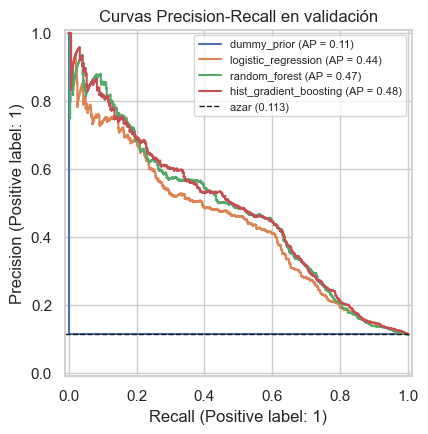

In [25]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, s in val_scores.items():
  if name == 'regla_poutcome_success':
    continue
  PrecisionRecallDisplay.from_predictions(y_val, s, name=name, ax=ax)
ax.axhline(y_val.mean(), ls='--', c='k', lw=1, label=f'azar ({y_val.mean():.3f})')
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Curvas Precision-Recall en validación')
save(fig, 'pr_curves_val')
plt.show()

**Lo que muestran los resultados.**
- Los tres modelos **cuadruplican la PR-AUC del dummy** (≈ 0.44–0.48 frente a 0.113) y duplican la de la regla de
  negocio (0.21). Llamando al 20 % de clientes con mayor score, captan ≈ 63–66 % de los suscriptores, frente a ≈ 20 %
  al azar y ≈ 34 % con la regla.
- En validación cruzada, HistGradientBoosting (0.466 ± 0.015) y Random Forest (0.462 ± 0.016) superan ligeramente a la
  regresión logística (0.446 ± 0.013). **La diferencia entre los dos modelos de árboles es menor que una desviación
  estándar entre folds**, así que todavía no es concluyente. La ventaja frente a la logística es pequeña pero
  consistente en CV y en validación.
- Las curvas PR muestran que, para los primeros clientes del ranking (recall de hasta ≈ 0.25), la precisión de los modelos de árboles supera 0.6. Es decir,
  el inicio de la lista concentra a los clientes más probables, que es justo lo que se necesita para priorizar.

**Selección para el TP1: `HistGradientBoosting`.** Tiene la mejor PR-AUC en CV y en validación, maneja la relación no
lineal de la edad sin ingeniería adicional y es el más rápido de los modelos de árboles. Se reconoce que el margen
frente a Random Forest no es significativo: esa comparación se repetirá en el TF1 con ajuste de hiperparámetros.

## 10. Evaluación final en test (una sola vez)

Se evalúan el modelo elegido, la regresión logística como referencia lineal y los dos baselines. Los umbrales son los
elegidos en validación.

In [26]:
SELECTED = 'hist_gradient_boosting'
test_rows = []
test_scores = {
  'dummy_prior': dummy.predict_proba(X_test)[:, 1],
  'regla_poutcome_success': rule_score(X_test),
  'logistic_regression': fitted['logistic_regression'].predict_proba(X_test)[:, 1],
  SELECTED: fitted[SELECTED].predict_proba(X_test)[:, 1],
}
thresholds = val_thresholds
for name, s in test_scores.items():
  test_rows.append({'modelo': name, 'umbral': thresholds[name],
                    **evaluate_scores(y_test, s, thresholds[name])})
test_table = results_table(test_rows)
RESULTS['test'] = test_table.reset_index().to_dict(orient='records')
test_table

,umbral,pr_auc,roc_auc,precision,recall,f1,capture_top20
modelo,,,,,,,
dummy_prior,0.113,0.113,0.500,0.113,1.000,0.203,0.187
regla_poutcome_success,0.500,0.206,0.584,0.627,0.181,0.281,0.313
logistic_regression,0.633,0.457,0.814,0.441,0.598,0.507,0.659
hist_gradient_boosting,0.212,0.498,0.825,0.480,0.603,0.535,0.674


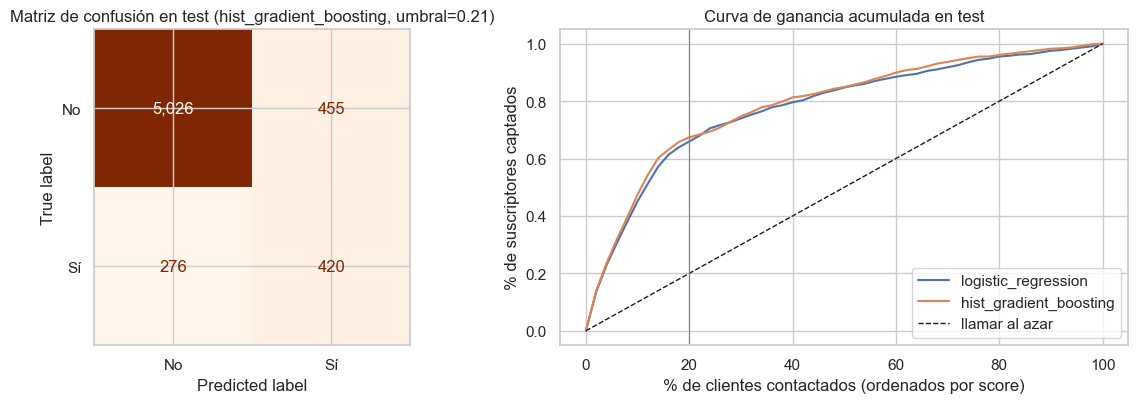

Suscriptores captados llamando al top 10/20/30/50 %: {'logistic_regression': [0.451, 0.659, 0.74, 0.848], 'hist_gradient_boosting': [0.474, 0.674, 0.747, 0.849]}


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
pred = (test_scores[SELECTED] >= thresholds[SELECTED]).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=['No', 'Sí']).plot(
  ax=axes[0], cmap='Oranges', colorbar=False, values_format=',')
axes[0].set_title(f'Matriz de confusión en test ({SELECTED}, umbral={thresholds[SELECTED]:.2f})')

ks = np.linspace(0, 1, 51)
for name in ['logistic_regression', SELECTED]:
  axes[1].plot(ks * 100, [capture_at_k(y_test, test_scores[name], k) if k > 0 else 0 for k in ks],
               label=name)
axes[1].plot([0, 100], [0, 1], 'k--', lw=1, label='llamar al azar')
axes[1].axvline(20, color='grey', lw=0.8)
axes[1].set_xlabel('% de clientes contactados (ordenados por score)')
axes[1].set_ylabel('% de suscriptores captados')
axes[1].set_title('Curva de ganancia acumulada en test')
axes[1].legend()
plt.tight_layout()
save(fig, 'test_confusion_gain')
plt.show()

cm = confusion_matrix(y_test, pred)
RESULTS['confusion_test'] = cm.tolist()
RESULTS['ganancia_test'] = {
  name: [round(float(capture_at_k(y_test, test_scores[name], k)), 3) for k in [0.1, 0.2, 0.3, 0.5]]
  for name in ['logistic_regression', SELECTED]
}
print('Suscriptores captados llamando al top 10/20/30/50 %:', RESULTS['ganancia_test'])

**Lo que muestran los resultados en test.**

| Métrica (test) | Dummy | Regla `poutcome` | Logística | **HGB (elegido)** |
|---|---|---|---|---|
| PR-AUC | 0.113 | 0.206 | 0.457 | **0.498** |
| ROC-AUC | 0.500 | 0.584 | 0.814 | **0.825** |
| % suscriptores captados en top 20 % | ≈ 19 % | 31 % | 66 % | **67 %** |

- El desempeño en test (PR-AUC 0.498) es coherente con validación (0.478) y con CV (0.466 ± 0.015): **no hay señales de
  sobreajuste a validación**.
- **Matriz de confusión** (umbral 0.21): de 6 177 clientes de test, el modelo recomienda llamar a 875 (14 %). Entre
  ellos hay 420 suscriptores reales (precisión 48 %, **4.3 veces la tasa base**), es decir, el 60 % de los 696
  suscriptores. Quedan 276 suscriptores sin detectar (falsos negativos) y 455 llamadas sin éxito (falsos positivos).
- La curva de ganancia muestra que llamar al 10 % superior capta ≈ 47 % de los suscriptores y el 30 % superior capta
  ≈ 75 %.

**Contraste con los criterios de utilidad (sección 1).**
1. PR-AUC muy por encima de la prevalencia y de la regla de negocio: ✅
2. Top 20 % capta ≥ 40 % de los suscriptores: ✅ (67 %)
3. Sin variables posteriores a la llamada: ✅ (`duration` excluida). **Con una salvedad importante:** este resultado
   supone que las campañas futuras se parecen a las de entrenamiento, lo cual se pone a prueba a continuación.

**Interpretación del umbral.** F1 da el mismo peso a precisión y recall. En la práctica, el umbral debería fijarse según
la **capacidad de llamadas** del banco (por ejemplo, "podemos llamar al 20 %") o según el costo de una llamada frente
al beneficio de un depósito. No tenemos esos costos, por lo que el umbral de F1 es una referencia provisional.

## 11. Prueba de estrés: ¿generaliza el modelo a períodos futuros?

El EDA (P5) mostró que la tasa de suscripción cambia fuertemente en el tiempo. Para estimar qué pasaría si el banco
usara el modelo en una campaña **posterior**, se repite el experimento con un **split temporal** que respeta el orden
de los registros: el primer 70 % para train, el siguiente 15 % para validation y el último 15 % para test. Se comparan
dos configuraciones: con y sin las variables macroeconómicas.

In [28]:
n = len(X)
a, b = int(0.70 * n), int(0.85 * n)
blocks = {'train': slice(0, a), 'validation': slice(a, b), 'test': slice(b, n)}
print({k: round(float(y.iloc[s].mean()), 3) for k, s in blocks.items()})

temporal_rows = []
configs = {
  'con macro': (NUM_FEATURES, CAT_FEATURES),
  'sin macro': ([c for c in NUM_FEATURES if c not in MACRO_NUM], CAT_FEATURES),
}
for cfg_name, (num_f, cat_f) in configs.items():
  for name in ['logistic_regression', 'hist_gradient_boosting']:
    pipe = build_pipeline(get_models()[name], num_f, cat_f).fit(X.iloc[blocks['train']],
                                                                 y.iloc[blocks['train']])
    for part in ['validation', 'test']:
      s = pipe.predict_proba(X.iloc[blocks[part]])[:, 1]
      m = evaluate_scores(y.iloc[blocks[part]], s)
      temporal_rows.append({'variables': cfg_name, 'modelo': name, 'bloque': part,
                            'prevalencia': y.iloc[blocks[part]].mean(),
                            'pr_auc': m['pr_auc'], 'roc_auc': m['roc_auc'],
                            'capture_top20': m['capture_top20']})
temporal_table = pd.DataFrame(temporal_rows).round(3)
RESULTS['temporal'] = temporal_table.to_dict(orient='records')
temporal_table

{'train': 0.056, 'validation': 0.106, 'test': 0.384}


,variables,modelo,bloque,prevalencia,pr_auc,roc_auc,capture_top20
0,con macro,logistic_regression,validation,0.106,0.189,0.660,0.393
1,con macro,logistic_regression,test,0.384,0.439,0.567,0.224
2,con macro,hist_gradient_boosting,validation,0.106,0.131,0.560,0.254
3,con macro,hist_gradient_boosting,test,0.384,0.385,0.492,0.201
4,sin macro,logistic_regression,validation,0.106,0.198,0.660,0.402
5,sin macro,logistic_regression,test,0.384,0.472,0.616,0.259
6,sin macro,hist_gradient_boosting,validation,0.106,0.212,0.654,0.379
7,sin macro,hist_gradient_boosting,test,0.384,0.445,0.601,0.247


**Lo que muestran los datos.**
- La prevalencia cambia de 5.6 % en train a 10.6 % en validation y 38.4 % en test: **las tres particiones temporales
  representan contextos muy distintos**.
- Con variables macro, el desempeño colapsa: el ROC-AUC baja de ≈ 0.81–0.83 (split aleatorio) a ≈ 0.49–0.66, y
  HistGradientBoosting queda **al nivel del azar en test** (ROC-AUC 0.49).
- Al **quitar las variables macro**, el resultado temporal mejora en todos los casos (por ejemplo, HGB en test pasa de
  ROC-AUC 0.49 a 0.60), aunque sigue lejos del split aleatorio. La PR-AUC en test temporal (0.38–0.47) debe leerse
  frente a su propia prevalencia (0.384), por lo que su mejora real es pequeña.

**Interpretación.**
1. En el split aleatorio, buena parte del desempeño viene de **reconocer el período**. Las variables macro (sobre todo
   `nr.employed`, con solo 11 valores distintos) funcionan como un "reloj" que en test toma valores ya vistos en train.
   En el futuro, esos valores no se han visto (en test temporal, `nr.employed` cae por debajo del mínimo observado en
   train), y los árboles no extrapolan.
2. El perfil del cliente y el historial de contacto sí generalizan, pero con una señal más débil.
3. **Conclusión honesta del TP1:** el modelo es útil para **ordenar clientes dentro de un contexto similar al de
   entrenamiento**, pero aún no está demostrado que funcione en una campaña futura con un contexto económico distinto.
   Este es el principal problema pendiente para el TF1.

## 12. Interpretación preliminar: ¿en qué se apoya el modelo?

Se usa **importancia por permutación** sobre validación: cuánto cae la PR-AUC si se desordena cada variable original.
Se aplica al pipeline completo, así que se mide sobre las variables crudas y no sobre las columnas one-hot. El análisis
completo con SHAP queda para el TF1.

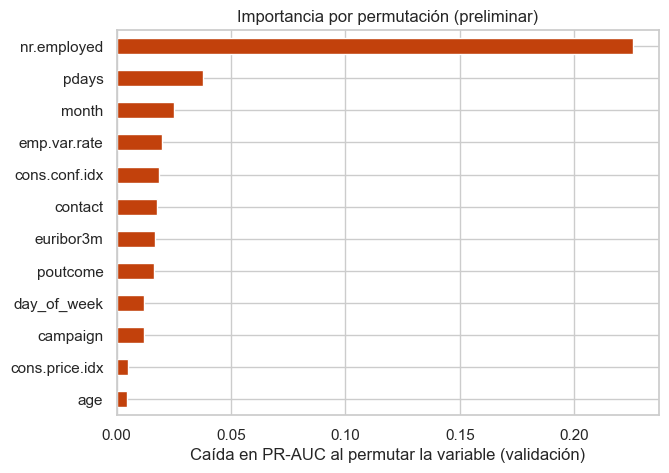

nr.employed      0.2259
pdays            0.0377
month            0.0251
emp.var.rate     0.0198
cons.conf.idx    0.0186
contact          0.0174
euribor3m        0.0168
poutcome         0.0164
day_of_week      0.0122
campaign         0.0121
dtype: float64

In [29]:
perm = permutation_importance(fitted[SELECTED], X_val, y_val, scoring='average_precision',
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
imp = pd.Series(perm.importances_mean, index=X_val.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
imp.tail(12).plot.barh(ax=ax, color=COLOR_YES)
ax.set_xlabel('Caída en PR-AUC al permutar la variable (validación)')
ax.set_title('Importancia por permutación (preliminar)')
save(fig, 'importancia_permutacion')
plt.show()
RESULTS['importancia'] = imp.sort_values(ascending=False).round(4).head(10).to_dict()
imp.sort_values(ascending=False).round(4).head(10)

**Lo que muestran los datos.** `nr.employed` domina por amplio margen (la PR-AUC cae ≈ 0.23 al permutarla). Le siguen,
muy lejos, `pdays` (convertida en `contacto_reciente`), `month`, otras variables macro, `contact` y `poutcome`.

**Interpretación y precauciones.**
- El modelo se apoya principalmente en **el contexto temporal y macroeconómico**, no en el perfil del cliente. Esto es
  coherente con la sección 11 y explica por qué falla en el split temporal.
- La permutación **subestima** la importancia de variables correlacionadas: si se permuta `euribor3m`, el modelo todavía
  puede usar `nr.employed` o `emp.var.rate`. Por eso la importancia individual de cada variable macro no es confiable,
  aunque **el bloque macro en conjunto** sí es claramente dominante.
- Importancia no es causalidad: que `nr.employed` sea importante no significa que el número de empleados *cause* la
  suscripción. Es una señal del período en que se hizo la campaña.

## 13. Artefacto de inferencia

Se guarda el pipeline completo (preprocesamiento + modelo) con `joblib` y se comprueba que puede cargarse y usarse
con datos crudos fuera del flujo de entrenamiento. Este es el artefacto que consumirá la aplicación del TF1. Para cargarlo
en otro programa deben estar definidas las clases `ContactHistoryFeatures` y `QuantileClipper` (sección 7).

In [30]:
MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(fitted[SELECTED], MODELS_DIR / 'modelo_tp1.joblib')
meta = {'modelo': SELECTED, 'umbral': thresholds[SELECTED],
        'test': {k: round(float(v), 4) for k, v in test_table.loc[SELECTED].items()}}
(MODELS_DIR / 'modelo_tp1_meta.json').write_text(json.dumps(meta, indent=2))
(REPORTS_DIR / 'resultados_tp1.json').write_text(json.dumps(RESULTS, indent=2, default=float))

# Prueba de inferencia fuera del flujo de entrenamiento: el pipeline recibe datos crudos
loaded = joblib.load(MODELS_DIR / 'modelo_tp1.joblib')
ejemplo = X_test.head(3)
pd.DataFrame({'probabilidad_suscripcion': loaded.predict_proba(ejemplo)[:, 1].round(3),
              'real': y_test.head(3).values}, index=ejemplo.index)

,probabilidad_suscripcion,real
8122,0.042,0
29245,0.056,0
2488,0.032,0


## 14. Estado del proyecto y plan hacia el TF1

### Principales hallazgos
1. **Problema bien planteado como ranking:** con un modelo sin leakage, llamar al 20 % de clientes mejor puntuados capta
   ≈ 67 % de los suscriptores en test (frente a 20 % al azar y 31 % con la regla de negocio), con PR-AUC 0.50 frente a
   0.11 del dummy.
2. **Leakage identificado y evitado:** `duration` tendría un AUC de 0.82 por sí sola, pero no está disponible antes de
   la llamada.
3. **Calidad de datos:** `unknown` es informativo (no se imputa), `pdays` es inconsistente con `previous` (se recodifica)
   y solo había 12 duplicados reales.
4. **Patrones de negocio:** el éxito previo, el canal celular, los clientes jóvenes o mayores de 60 años y las primeras
   llamadas se asocian con mayor conversión. Insistir con muchas llamadas tiene rendimientos decrecientes.
5. **Hallazgo crítico:** el desempeño depende fuertemente del **contexto temporal y macroeconómico**. Con split temporal,
   el modelo pierde gran parte de su capacidad.

### Problemas aún no resueltos
- No sabemos si el modelo sirve para **campañas futuras** (sección 11).
- `campaign` y `month`/`day_of_week` describen el **último** contacto. Falta definir con precisión qué información está
  disponible al decidir cada llamada, porque podría existir un leakage sutil.
- El umbral se eligió por F1, sin costos reales de llamada ni beneficio por depósito.
- La diferencia entre HistGradientBoosting y Random Forest no es significativa.

### Limitaciones identificadas
- Un banco, un país y un período de crisis: **no es generalizable** a otros bancos ni a contextos económicos distintos.
- Sin ID de cliente: posibles clientes repetidos entre train y test, lo que hace el split aleatorio algo optimista.
- No se puede separar el efecto del contexto económico del efecto de cambios en la estrategia de la campaña.
- Las asociaciones encontradas no son causales: el modelo prioriza clientes, pero no explica por qué suscriben.

### Plan de trabajo hacia el TF1

| Semana | Actividad | Herramienta | Conecta con |
|---|---|---|---|
| 8–9 | Validación temporal con ventana expansiva (*rolling origin*); conjuntos de variables con y sin bloque macro y calendario; revisar el leakage de `campaign` | `TimeSeriesSplit`, pipelines actuales | Sección 11 y problemas pendientes |
| 9–10 | Ajuste de hiperparámetros de HGB, RF y logística, con registro de experimentos | Optuna + MLflow | Experimentación sistemática |
| 10–11 | Resumir el bloque macro con **PCA** (redundancia ρ > 0.9) y **segmentar clientes** con clustering (K-Means) para analizar el desempeño por segmento | PCA, K-Means | Técnica de la segunda mitad del curso |
| 11–12 | Interpretabilidad global y local; calibración de probabilidades | SHAP, `CalibratedClassifierCV` | Interpretabilidad |
| 12 | Análisis de errores: FP/FN por segmento, edad, canal y período | pandas, matplotlib | Análisis de errores |
| 13–14 | App de priorización: el usuario carga clientes y obtiene una lista ordenada y el % esperado de captación | Streamlit (+ Docker opcional) | Despliegue |
| 14–15 | README final, diagrama de arquitectura, tabla de evolución TP1 → TF1 y presentación | — | Documentación |

## 15. Matriz de decisiones de herramientas (versión TP1)

| Necesidad | Herramienta elegida | Alternativa considerada | Justificación |
|---|---|---|---|
| EDA | pandas + matplotlib/seaborn | ydata-profiling | El EDA se guía por preguntas concretas; un reporte automático genera muchos gráficos sin interpretación. |
| Preparación | `Pipeline` + `ColumnTransformer` + transformadores propios | Preprocesar el DataFrame a mano | Garantiza que todo lo que aprende de los datos se ajuste solo en train (sin leakage) y que la app use exactamente las mismas transformaciones. |
| Separación | Hold-out estratificado 70/15/15 + CV de 5 folds | Split temporal | El estratificado da estimaciones estables para comparar modelos; el temporal se usa como prueba de estrés y pasará a primer plano en el TF1. |
| Modelamiento | Logística, Random Forest, HistGradientBoosting (scikit-learn) | XGBoost / LightGBM | HGB ofrece un rendimiento similar dentro de scikit-learn, con menos dependencias. Se reevaluará en el TF1 si el ajuste lo justifica. |
| Métricas | PR-AUC + % captado en top 20 % | Accuracy | Con 11 % de positivos, la accuracy es engañosa (88.7 % sin modelo). La captación en el top k traduce el resultado a la decisión de negocio. |
| Experimentación | `cross_validate` (TP1) → Optuna + MLflow (TF1) | GridSearchCV | Optuna explora el espacio de búsqueda de forma más eficiente y MLflow permite rastrear qué configuración produjo cada resultado. |
| Interpretabilidad | Importancia por permutación (TP1) → SHAP (TF1) | Coeficientes de la logística | Los coeficientes son inestables por la multicolinealidad del bloque macro. |
| Despliegue | Streamlit (TF1) | FastAPI | El usuario objetivo (área comercial) necesita una interfaz para cargar listas de clientes, no un servicio API. |